In [14]:
from google.colab import files
files.upload()

Saving kaggle (3).json to kaggle (3) (1).json


{'kaggle (3) (1).json': b'{"username":"saishanthv","key":"92599c1d7c47b4d7821dabdd345c4a7c"}'}

In [15]:
!mv "kaggle (3) (1).json" kaggle.json

In [16]:
!pip install kaggle

In [17]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [18]:
!kaggle datasets download -d wordsforthewise/lending-club

Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
License(s): CC0-1.0
 99% 1.25G/1.26G [00:11<00:00, 78.3MB/s]
100% 1.26G/1.26G [00:11<00:00, 115MB/s] 


In [19]:
import zipfile
with zipfile.ZipFile("lending-club.zip", "r") as zip_ref:
    zip_ref.extractall("lending_data")

In [20]:
import os
os.listdir("lending_data")

['accepted_2007_to_2018Q4.csv.gz',
 'accepted_2007_to_2018q4.csv',
 'rejected_2007_to_2018Q4.csv.gz',
 'rejected_2007_to_2018q4.csv']

In [21]:
import os
for root, dirs, files in os.walk("lending_data"):
    for file in files:
        print(os.path.join(root, file))

lending_data/accepted_2007_to_2018Q4.csv.gz
lending_data/rejected_2007_to_2018Q4.csv.gz
lending_data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
lending_data/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv


In [22]:
import pandas as pd
df = pd.read_csv(
    "lending_data/accepted_2007_to_2018Q4.csv.gz",
    compression="gzip",
    low_memory=False
)
print(df.shape)
df.head()

(2260701, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df.columns.tolist()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [24]:
df_sample = df.sample(100000, random_state=42)
print(df_sample.shape)

(100000, 151)


In [25]:
df_sample.to_csv("lendingclub_sample.csv", index=False)

In [26]:
df_sample["loan_status"].value_counts()

,count
loan_status,
Fully Paid,47460
Current,38887
Charged Off,12034
Late (31-120 days),969
In Grace Period,368
Late (16-30 days),187
Does not meet the credit policy. Status:Fully Paid,60
Does not meet the credit policy. Status:Charged Off,31


In [27]:
df_model = df_sample[df_sample["loan_status"].isin(["Fully Paid", "Charged Off"])]
print(df_model["loan_status"].value_counts())
print(df_model.shape)

loan_status
Fully Paid     47460
Charged Off    12034
Name: count, dtype: int64
(59494, 151)


In [28]:
df_model["target"] = df_model["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})
df_model[["loan_status", "target"]].head()

/tmp/ipykernel_1303/3328048770.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["target"] = df_model["loan_status"].map({


,loan_status,target
1273506,Fully Paid,0
324024,Fully Paid,0
2066630,Fully Paid,0
1975547,Fully Paid,0
302723,Fully Paid,0


In [29]:
df_model["target"].value_counts(normalize=True)

,proportion
target,
0,0.797728
1,0.202272


In [30]:
features = [
    "loan_amnt",
    "term",
    "int_rate",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "purpose",
    "dti",
    "delinq_2yrs",
    "revol_bal",
    "total_acc",
    "verification_status"
]

df_model = df_model[features + ["target"]]

df_model.head()

,loan_amnt,term,int_rate,emp_length,home_ownership,annual_inc,purpose,dti,delinq_2yrs,revol_bal,total_acc,verification_status,target
1273506,9600.0,36 months,12.99,NaN,RENT,21900.0,debt_consolidation,10.03,0.0,4509.0,20.0,Verified,0
324024,4000.0,36 months,6.68,4 years,MORTGAGE,83000.0,major_purchase,19.53,0.0,1564.0,25.0,Not Verified,0
2066630,6025.0,36 months,10.91,10+ years,RENT,52000.0,debt_consolidation,9.16,1.0,2706.0,25.0,Not Verified,0
1975547,20000.0,36 months,9.49,10+ years,MORTGAGE,100000.0,debt_consolidation,16.43,1.0,20440.0,32.0,Not Verified,0
302723,1000.0,36 months,8.18,NaN,RENT,23000.0,debt_consolidation,16.34,1.0,3237.0,38.0,Verified,0


In [31]:
df_model.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
emp_length,3470
home_ownership,0
annual_inc,0
purpose,0
dti,20
delinq_2yrs,0
revol_bal,0


In [32]:
df_model["emp_length"].value_counts()

,count
emp_length,
10+ years,19537
2 years,5449
< 1 year,4851
3 years,4705
1 year,3852
5 years,3682
4 years,3602
6 years,2778
7 years,2683


In [33]:
df_model["emp_length"].fillna(df_model["emp_length"].mode()[0], inplace=True)

/tmp/ipykernel_1303/727036853.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model["emp_length"].fillna(df_model["emp_length"].mode()[0], inplace=True)


In [34]:
df_model["dti"].fillna(df_model["dti"].median(), inplace=True)

/tmp/ipykernel_1303/322540745.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model["dti"].fillna(df_model["dti"].median(), inplace=True)


In [35]:
df_model.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
emp_length,0
home_ownership,0
annual_inc,0
purpose,0
dti,0
delinq_2yrs,0
revol_bal,0


In [36]:
df_model["int_rate"].dtype

dtype('float64')

In [37]:
df_model["term"].value_counts()

,count
term,
36 months,45061
60 months,14433


In [38]:
df_model["term"] = df_model["term"].str.replace(" months", "").astype(int)

In [39]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [40]:
df_model.shape

(59494, 39)

In [41]:
X = df_model.drop("target", axis=1)
y = df_model["target"]

print(X.shape)
print(y.shape)

(59494, 38)
(59494,)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(47595, 38)
(11899, 38)


In [43]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [44]:
y_pred = log_model.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7996470291621145
[[9370  135]
 [2249  145]]
              precision    recall  f1-score   support

           0       0.81      0.99      0.89      9505
           1       0.52      0.06      0.11      2394

    accuracy                           0.80     11899
   macro avg       0.66      0.52      0.50     11899
weighted avg       0.75      0.80      0.73     11899



In [46]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [47]:
y_pred_rf = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8007395579460459
[[9368  137]
 [2234  160]]
              precision    recall  f1-score   support

           0       0.81      0.99      0.89      9505
           1       0.54      0.07      0.12      2394

    accuracy                           0.80     11899
   macro avg       0.67      0.53      0.50     11899
weighted avg       0.75      0.80      0.73     11899



In [48]:
import pandas as pd
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
print(feature_importance.head(10))

int_rate                               0.157894
dti                                    0.137778
revol_bal                              0.131160
annual_inc                             0.119559
loan_amnt                              0.110106
total_acc                              0.107906
delinq_2yrs                            0.026241
term                                   0.022936
emp_length_10+ years                   0.015772
verification_status_Source Verified    0.014221
dtype: float64


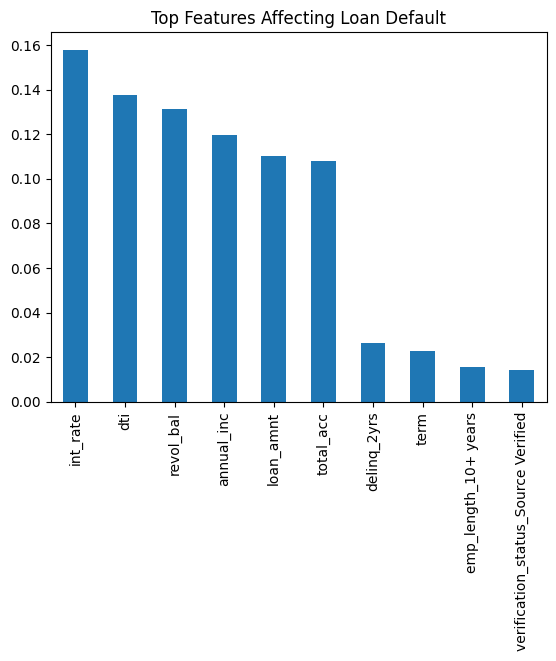

In [49]:
import matplotlib.pyplot as plt
feature_importance.head(10).plot(kind="bar")
plt.title("Top Features Affecting Loan Default")
plt.show()

In [50]:
from sklearn.linear_model import LogisticRegression

log_model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
log_model_balanced.fit(X_train, y_train)
y_pred_bal = log_model_balanced.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print(confusion_matrix(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

Accuracy: 0.6493823010337003
[[6220 3285]
 [ 887 1507]]
              precision    recall  f1-score   support

           0       0.88      0.65      0.75      9505
           1       0.31      0.63      0.42      2394

    accuracy                           0.65     11899
   macro avg       0.59      0.64      0.58     11899
weighted avg       0.76      0.65      0.68     11899



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:
from sklearn.ensemble import RandomForestClassifier
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
rf_balanced.fit(X_train, y_train)
y_pred_rf_bal = rf_balanced.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf_bal))
print(confusion_matrix(y_test, y_pred_rf_bal))
print(classification_report(y_test, y_pred_rf_bal))

Accuracy: 0.7982183376754349
[[9380  125]
 [2276  118]]
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      9505
           1       0.49      0.05      0.09      2394

    accuracy                           0.80     11899
   macro avg       0.65      0.52      0.49     11899
weighted avg       0.74      0.80      0.73     11899



In [52]:
import pandas as pd
feature_importance = pd.Series(
    rf_balanced.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
int_rate,0.176014
dti,0.133934
revol_bal,0.126272
annual_inc,0.115531
loan_amnt,0.107055
total_acc,0.103916
term,0.027843
delinq_2yrs,0.024687
emp_length_10+ years,0.015230
verification_status_Source Verified,0.014214


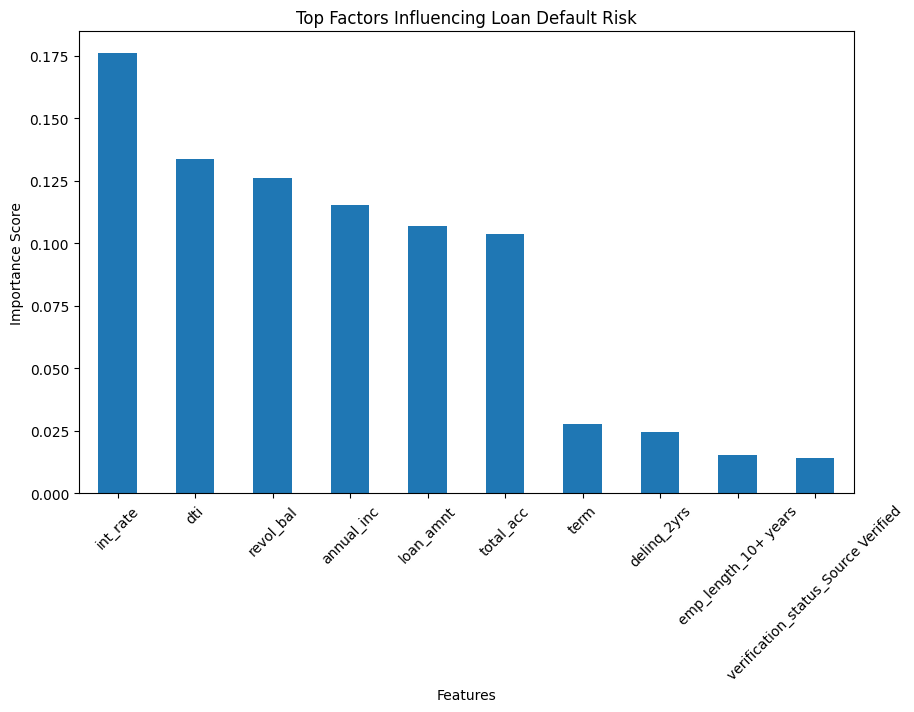

In [53]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind="bar")
plt.title("Top Factors Influencing Loan Default Risk")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.show()

In [54]:
purpose_risk = df_model.groupby("purpose_credit_card")["target"].mean()
print(purpose_risk)

purpose_credit_card
False    0.210110
True     0.174631
Name: target, dtype: float64


In [55]:
risk_by_home = df_sample.groupby("home_ownership")["loan_status"].value_counts(normalize=True)
print(risk_by_home)

home_ownership  loan_status                                        
ANY             Current                                                0.688889
                Fully Paid                                             0.266667
                Charged Off                                            0.022222
                Late (31-120 days)                                     0.022222
MORTGAGE        Fully Paid                                             0.494785
                Current                                                0.383733
                Charged Off                                            0.107466
                Late (31-120 days)                                     0.008279
                In Grace Period                                        0.003238
                Late (16-30 days)                                      0.001701
                Does not meet the credit policy. Status:Fully Paid     0.000553
                Does not meet the credit policy. Sta

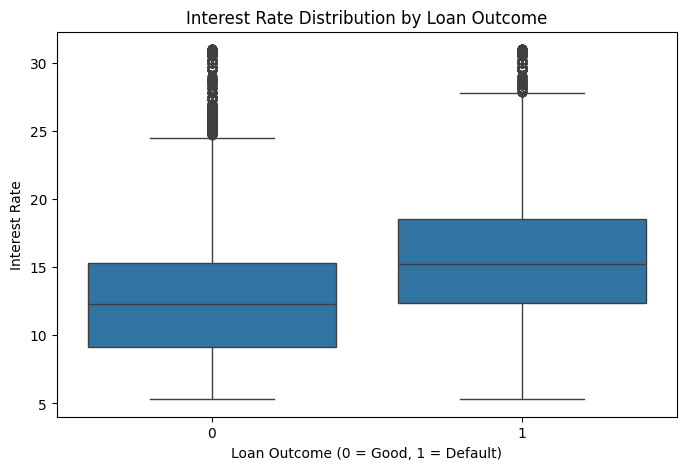

In [56]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="int_rate", data=df_model)
plt.title("Interest Rate Distribution by Loan Outcome")
plt.xlabel("Loan Outcome (0 = Good, 1 = Default)")
plt.ylabel("Interest Rate")
plt.show()

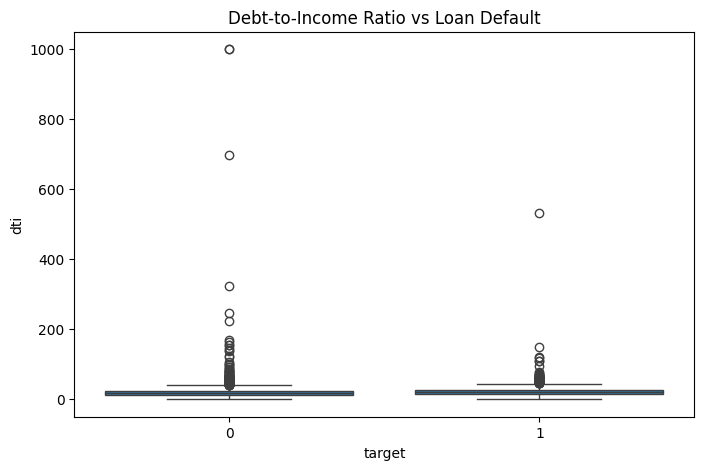

In [57]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="dti", data=df_model)
plt.title("Debt-to-Income Ratio vs Loan Default")
plt.show()

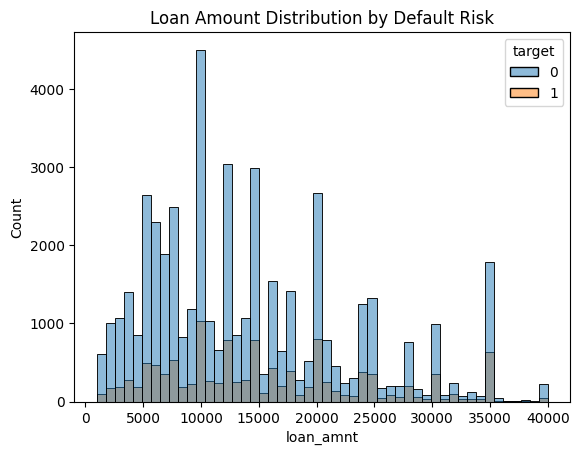

In [58]:
sns.histplot(data=df_model, x="loan_amnt", hue="target", bins=50)
plt.title("Loan Amount Distribution by Default Risk")
plt.show()

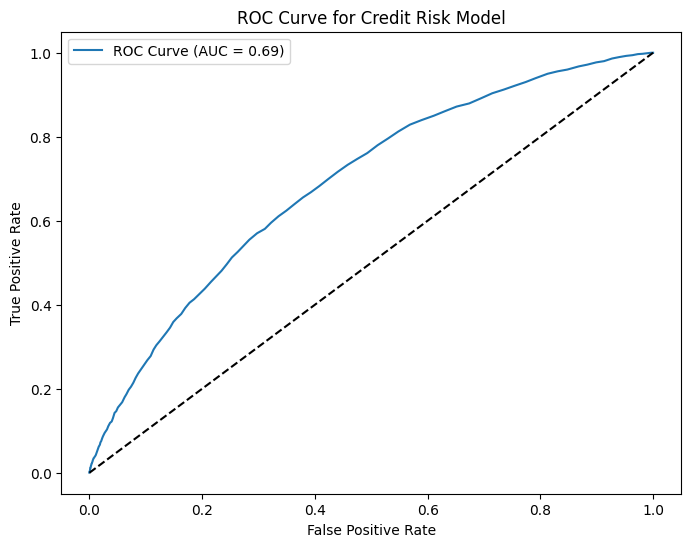

In [59]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# predicted probabilities
y_prob = rf_balanced.predict_proba(X_test)[:,1]

# compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Credit Risk Model")
plt.legend()
plt.show()

In [60]:
results = X_test.copy()
results["actual_default"] = y_test.values
results["default_probability"] = y_prob
results.head()

,loan_amnt,term,int_rate,annual_inc,dti,delinq_2yrs,revol_bal,total_acc,emp_length_10+ years,emp_length_2 years,...,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,verification_status_Source Verified,verification_status_Verified,actual_default,default_probability
1296932,18000.0,36,7.90,40000.0,18.82,1.0,22027.0,28.0,False,True,...,False,False,False,False,False,False,False,False,0,0.105
1843927,12000.0,36,7.90,49000.0,14.69,0.0,9563.0,25.0,True,False,...,False,False,False,False,False,False,True,False,1,0.030
1291888,20000.0,60,14.64,65000.0,21.42,0.0,20320.0,30.0,False,False,...,False,False,False,False,False,False,False,True,0,0.160
1740805,6000.0,36,14.99,88000.0,20.21,0.0,17266.0,24.0,False,False,...,False,False,False,False,False,False,False,True,0,0.160
1772444,1800.0,36,21.70,29000.0,22.31,0.0,2021.0,26.0,False,False,...,False,False,False,False,True,False,False,True,1,0.210


In [61]:
results["risk_score"] = (results["default_probability"] * 100).round(1)
results[["default_probability","risk_score"]].head()

,default_probability,risk_score
1296932,0.105,10.5
1843927,0.030,3.0
1291888,0.160,16.0
1740805,0.160,16.0
1772444,0.210,21.0


In [62]:
def risk_band(p):
    if p < 0.20:
        return "Low Risk"
    elif p < 0.50:
        return "Medium Risk"
    else:
        return "High Risk"
results["risk_band"] = results["default_probability"].apply(risk_band)
results["risk_band"].value_counts()

,count
risk_band,
Low Risk,6730
Medium Risk,4913
High Risk,256


In [63]:
def approval_decision(p):
    if p < 0.20:
        return "Approve"
    elif p < 0.50:
        return "Manual Review"
    else:
        return "Reject"
results["decision"] = results["default_probability"].apply(approval_decision)
results[["default_probability","risk_band","decision"]].head(10)

,default_probability,risk_band,decision
1296932,0.105,Low Risk,Approve
1843927,0.030,Low Risk,Approve
1291888,0.160,Low Risk,Approve
1740805,0.160,Low Risk,Approve
1772444,0.210,Medium Risk,Manual Review
564520,0.130,Low Risk,Approve
1643632,0.195,Low Risk,Approve
945227,0.150,Low Risk,Approve
450446,0.375,Medium Risk,Manual Review
2130662,0.140,Low Risk,Approve


In [64]:
risk_summary = results.groupby("risk_band").agg(
    applicants=("risk_band","count"),
    avg_score=("risk_score","mean"),
    actual_default_rate=("actual_default","mean")
).reset_index()
risk_summary

,risk_band,applicants,avg_score,actual_default_rate
0,High Risk,256,55.632812,0.484375
1,Low Risk,6730,11.426969,0.122585
2,Medium Risk,4913,30.157643,0.294118


In [65]:
results.to_csv("loan_risk_predictions.csv",index=False)
risk_summary.to_csv("risk_summary.csv",index=False)

In [66]:
import pandas as pd
import sqlite3
from datetime import datetime

In [67]:
df_sample.to_csv("sample_raw_lending_data.csv", index=False)

In [68]:
df_model.to_csv("processed_model_data.csv", index=False)

In [69]:
results.to_csv("loan_risk_predictions.csv", index=False)

In [70]:
risk_summary.to_csv("risk_summary.csv", index=False)

In [71]:
conn = sqlite3.connect("credit_risk_pipeline.db")

In [72]:
df_sample.to_sql("raw_lending_sample", conn, if_exists="replace", index=False)

100000

In [73]:
df_model.to_sql("processed_loan_model_data", conn, if_exists="replace", index=False)

59494

In [74]:
results.to_sql("loan_scoring_results", conn, if_exists="replace", index=False)

11899

In [75]:
risk_summary.to_sql("risk_summary", conn, if_exists="replace", index=False)

3

In [76]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,raw_lending_sample
1,processed_loan_model_data
2,loan_scoring_results
3,risk_summary


In [77]:
query_risk_band = """
SELECT
    risk_band,
    COUNT(*) AS applicant_count
FROM loan_scoring_results
GROUP BY risk_band
ORDER BY applicant_count DESC;
"""

In [78]:
pd.read_sql(query_risk_band, conn)

,risk_band,applicant_count
0,Low Risk,6730
1,Medium Risk,4913
2,High Risk,256


In [79]:
query_decision = """
SELECT
    decision,
    COUNT(*) AS total_cases,
    ROUND(AVG(risk_score), 2) AS avg_risk_score
FROM loan_scoring_results
GROUP BY decision
ORDER BY avg_risk_score DESC;
"""

In [80]:
pd.read_sql(query_decision, conn)

,decision,total_cases,avg_risk_score
0,Reject,256,55.63
1,Manual Review,4913,30.16
2,Approve,6730,11.43


In [81]:
query_default_rate = """
SELECT
    risk_band,
    COUNT(*) AS applicants,
    ROUND(AVG(actual_default), 4) AS actual_default_rate
FROM loan_scoring_results
GROUP BY risk_band
ORDER BY actual_default_rate DESC;
"""

In [82]:
pd.read_sql(query_default_rate, conn)

,risk_band,applicants,actual_default_rate
0,High Risk,256,0.4844
1,Medium Risk,4913,0.2941
2,Low Risk,6730,0.1226


In [83]:
query_high_risk = """
SELECT
    loan_amnt,
    int_rate,
    annual_inc,
    dti,
    risk_score,
    risk_band,
    decision
FROM loan_scoring_results
WHERE risk_band = 'High Risk'
LIMIT 20;
"""

In [84]:
pd.read_sql(query_high_risk, conn)

,loan_amnt,int_rate,annual_inc,dti,risk_score,risk_band,decision
0,20000.0,20.89,65000.0,24.55,60.0,High Risk,Reject
1,34875.0,18.25,100000.0,12.49,51.0,High Risk,Reject
2,11200.0,18.54,30000.0,32.44,51.0,High Risk,Reject
3,11275.0,27.49,35000.0,15.31,71.5,High Risk,Reject
4,21575.0,21.99,54000.0,17.38,52.0,High Risk,Reject
5,16500.0,14.49,46243.0,32.52,55.5,High Risk,Reject
6,7300.0,19.19,41600.0,22.42,57.0,High Risk,Reject
7,32000.0,17.97,98000.0,7.80,53.5,High Risk,Reject
8,35000.0,18.99,97100.0,24.71,57.5,High Risk,Reject
9,18675.0,25.89,52000.0,23.45,51.0,High Risk,Reject


In [85]:
query_decision_distribution = """
SELECT
    decision,
    COUNT(*) AS total
FROM loan_scoring_results
GROUP BY decision
ORDER BY total DESC;
"""

In [86]:
pd.read_sql(query_decision_distribution, conn)

,decision,total
0,Approve,6730
1,Manual Review,4913
2,Reject,256


In [87]:
dashboard_table = results[[
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "revol_bal",
    "total_acc",
    "actual_default",
    "default_probability",
    "risk_score",
    "risk_band",
    "decision"
]].copy()

In [88]:
dashboard_table.head()

,loan_amnt,int_rate,annual_inc,dti,delinq_2yrs,revol_bal,total_acc,actual_default,default_probability,risk_score,risk_band,decision
1296932,18000.0,7.90,40000.0,18.82,1.0,22027.0,28.0,0,0.105,10.5,Low Risk,Approve
1843927,12000.0,7.90,49000.0,14.69,0.0,9563.0,25.0,1,0.030,3.0,Low Risk,Approve
1291888,20000.0,14.64,65000.0,21.42,0.0,20320.0,30.0,0,0.160,16.0,Low Risk,Approve
1740805,6000.0,14.99,88000.0,20.21,0.0,17266.0,24.0,0,0.160,16.0,Low Risk,Approve
1772444,1800.0,21.70,29000.0,22.31,0.0,2021.0,26.0,1,0.210,21.0,Medium Risk,Manual Review


In [89]:
dashboard_table.to_csv("dashboard_loan_risk_data.csv", index=False)

In [90]:
pipeline_log = pd.DataFrame({
    "stage": [
        "raw_data_ingestion",
        "data_cleaning",
        "feature_engineering",
        "model_training",
        "risk_scoring",
        "dashboard_export"
    ],
    "status": [
        "completed",
        "completed",
        "completed",
        "completed",
        "completed",
        "completed"
    ],
    "timestamp": [datetime.now().strftime("%Y-%m-%d %H:%M:%S")] * 6
})

In [91]:
pipeline_log

,stage,status,timestamp
0,raw_data_ingestion,completed,2026-03-14 03:31:46
1,data_cleaning,completed,2026-03-14 03:31:46
2,feature_engineering,completed,2026-03-14 03:31:46
3,model_training,completed,2026-03-14 03:31:46
4,risk_scoring,completed,2026-03-14 03:31:46
5,dashboard_export,completed,2026-03-14 03:31:46


In [92]:
pipeline_log.to_sql("pipeline_run_log", conn, if_exists="replace", index=False)

6

In [93]:
pd.read_sql("SELECT * FROM pipeline_run_log;", conn)

,stage,status,timestamp
0,raw_data_ingestion,completed,2026-03-14 03:31:46
1,data_cleaning,completed,2026-03-14 03:31:46
2,feature_engineering,completed,2026-03-14 03:31:46
3,model_training,completed,2026-03-14 03:31:46
4,risk_scoring,completed,2026-03-14 03:31:46
5,dashboard_export,completed,2026-03-14 03:31:46


In [94]:
sql_script = """
SELECT
    risk_band,
    COUNT(*) AS applicant_count
FROM loan_scoring_results
GROUP BY risk_band
ORDER BY applicant_count DESC;

SELECT
    decision,
    COUNT(*) AS total_cases,
    ROUND(AVG(risk_score), 2) AS avg_risk_score
FROM loan_scoring_results
GROUP BY decision
ORDER BY avg_risk_score DESC;

SELECT
    risk_band,
    COUNT(*) AS applicants,
    ROUND(AVG(actual_default), 4) AS actual_default_rate
FROM loan_scoring_results
GROUP BY risk_band
ORDER BY actual_default_rate DESC;

SELECT
    loan_amnt,
    int_rate,
    annual_inc,
    dti,
    risk_score,
    risk_band,
    decision
FROM loan_scoring_results
WHERE risk_band = 'High Risk'
LIMIT 20;

SELECT
    decision,
    COUNT(*) AS total
FROM loan_scoring_results
GROUP BY decision
ORDER BY total DESC;
"""

In [95]:
with open("sql_queries.sql", "w") as f:
    f.write(sql_script)

In [96]:
conn.close()

In [97]:
print("SQL + AWS-style pipeline simulation completed successfully.")

SQL + AWS-style pipeline simulation completed successfully.
